# Environment setup and Variables

In [ ]:
!pip -q install bitsandbytes accelerate
!pip -q install langchain
!pip install einops
!pip install --upgrade --quiet  langchain-community qdrant-client
!pip install langchainhub
!pip install -U langchain-huggingface
!pip -q install PyMuPDF tqdm aiolimiter faiss-cpu PyPDF2 pdfplumber rouge-score bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 105.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from spacy.lang.en import English
import fitz
import random
from tqdm.auto import tqdm
from time import perf_counter as timer
import textwrap
from sentence_transformers import util
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import AutoProcessor, AutoModelForVision2Seq
from PIL import Image
import requests
import ast
from langchain.text_splitter import TokenTextSplitter
from transformers import MllamaForConditionalGeneration, AutoProcessor
from torch.nn.functional import normalize
import time, statistics, asyncio, openai
import nest_asyncio
from google.colab import userdata
from aiolimiter import AsyncLimiter
import urllib.parse, pathlib
import html, unicodedata, logging
import spacy
import tiktoken
from torch.nn.functional import normalize as l2_normalize
import math
import faiss
from pathlib import Path
import json
from typing import List, Dict, Tuple, Optional, Sequence, Union, Iterable
import warnings
warnings.filterwarnings("ignore")
import PyPDF2
import pdfplumber
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import pipeline
from rouge_score import rouge_scorer
from bert_score import score as bert_score
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Load Documents

Testing on one document first

In [ ]:
#Add more documents once pipeline is solid
pdf_paths = ['/content/drive/MyDrive/fMRIwork/rag_docs/ales.pdf','/content/drive/MyDrive/fMRIwork/rag_docs/sages.pdf']

In [ ]:
doi_re     = re.compile(r"\b10\.\d{4,9}/[-._;()/:A-Za-z0-9]+\b")

def infer_source(doc: fitz.Document, pdf_path: str | pathlib.Path) -> str:
    """
    Get source label for a PDF

    Priority:
    1. DOI in XMP or first page          → 'DOI:10.1145/1234567'
    2. Domain extracted from URL         → 'arxiv.org' / 'springer.com'
    3. Base filename                     → 'my_paper.pdf'
    """
    meta_text = " ".join(str(v) for v in doc.metadata.values() if v)
    page1_text = doc[0].get_text() if len(doc) else ""
    haystack = f"{meta_text} {page1_text}"

    if (m := doi_re.search(haystack)):
        return f"DOI:{m.group(0)}"

    # Look for HTTPS path
    url = str(pdf_path)
    if urllib.parse.urlparse(url).scheme in {"http", "https"}:
        domain = urllib.parse.urlparse(url).netloc
        if domain:
            return domain

    # fallback to filename
    return pathlib.Path(url).name

In [ ]:
def open_and_read_pdfs(pdf_paths, *, start_doc_num=0, text_formatter=lambda x: x):
    pages = []
    doc_num = start_doc_num
    enc = tiktoken.get_encoding("cl100k_base")

    for path in pdf_paths:
        with fitz.open(path) as doc:
            doc_source = infer_source(doc, path)
            for page_num, page in enumerate(doc):
                txt = text_formatter(page.get_text())
                pages.append({
                    "doc_num": doc_num,
                    "doc_source": doc_source,  #Doc name
                    "page_number": page_num,
                    "page_char_count": len(txt),
                    "page_word_count": len(txt.split()),
                    "page_sentence_count_raw": len(txt.split(". ")),
                    "page_token_count": len(enc.encode(txt)),
                    "text": txt
                })
        doc_num += 1
    return pages

In [ ]:
pages = open_and_read_pdfs(pdf_paths)

In [ ]:
pages

[{'doc_num': 0,
  'doc_source': 'DOI:10.21037/ales.2020.02.06',
  'page_number': 0,
  'page_char_count': 4143,
  'page_word_count': 575,
  'page_sentence_count_raw': 26,
  'page_token_count': 994,
  'text': 'Page 1 of 4\n© Annals of Laparoscopic and Endoscopic Surgery. All rights reserved.\n  Ann Laparosc Endosc Surg 2020;5:15 | http://dx.doi.org/10.21037/ales.2020.02.06\nIntroduction\nIn the United States, gallstone disease remains a prevalent \ncondition affecting over 20 to 25 million Americans, \nrepresenting 10–15% of the population (1,2). Although not \nevery patient with gallstones will manifest symptoms or \nrequire intervention, laparoscopic cholecystectomy (LC), \nwhich accounts for 90% of all cholecystectomies, remains \none of the most commonly performed procedures—\nconservatively numbering 750,000 per year (3). Since its \nintroduction in the 1980s and subsequent adoption, LC \nhas become the standard of care due to its advantages of \nreduced cost and hospital length of 

In [ ]:
num_pages = len(pages)
num_docs = pages[-1]["doc_num"] + 1

print(f"{num_docs} documents in total")
print(f"{num_pages} pages in total")

2 documents in total
40 pages in total


#Sentenize and Clean Sentences

In [ ]:
nlp = spacy.blank("en")
nlp.add_pipe("sentencizer")

In [ ]:
bullet_re = re.compile(r"[•●▪■◦◆▶►‣❖⚫⬤➤➣➢\u2022\u25CF\u25A0]")
dehyphen_re = re.compile(r"(\w+)-\s*\n\s*(\w+)")
nbsp_re     = re.compile(r"\u00A0+")

header_footer_re = re.compile(r"""
    ^(
        [•●▪■◦◆▶►‣❖⚫⬤➤➣➢]?\s*     # optional bullet glyphs
        (page|p)\s*\d+(\s*/\s*\d+)? |   # Page 3 / 3/12
        [•●▪■◦◆▶►‣❖⚫⬤➤➣➢]?\s*
        figure\s+\d+               |   # Figure 2
        [•●▪■◦◆▶►‣❖⚫⬤➤➣➢]?\s*
        table\s+\d+                |   # Table 5
        ©.+?$                      |
        (all\s+rights\s+reserved)  |
        this\s+page\s+intentionally\s+left\s+blank |
        confidential               |
        copyright                  |
        doi:\s*10\.\d{4,9}/\S+     |
        \s*$                           # empty / whitespace-only line
    )
""", re.IGNORECASE | re.VERBOSE)

In [ ]:
def _normalize_whitespace(txt: str) -> str:
    txt = nbsp_re.sub(" ", txt)
    txt = bullet_re.sub(" ", txt)
    txt = unicodedata.normalize("NFKC", txt)
    return " ".join(txt.split()).strip()

In [ ]:
def split_sentences(text: str) -> List[str]:
    """ spaCy-based sentence splitter """
    text = dehyphen_re.sub(r"\1\2", text)         # undo line-break hyphenation
    text = html.unescape(text)                     # &amp; -> &
    text = _normalize_whitespace(text)

    if nlp:
        doc = nlp(text)
        return [s.text.strip() for s in doc.sents if s.text.strip()]
    else:
        crude = re.split(r"(?<=[.!?])\s{1,}", text)
        return [s.strip() for s in crude if s.strip()]

In [ ]:
def clean_sentence(sentence: str) -> str:
    """
    Remove headers, footers, boilerplate, short artifacts,
    and normalize whitespace.  Returns '' if the sentence should be skipped.
    """
    sentence = _normalize_whitespace(sentence)

    # strip lines that are obviously boilerplate
    if header_footer_re.match(sentence):
        return ""

    # very short fragments
    if len(sentence) < 6:
        return ""

    return sentence

In [ ]:
def sentences_from_pdf_text(raw_text: str) -> List[str]:
    """Extract -> clean -> return a flat list of good sentences."""
    sents = split_sentences(raw_text)
    sents = [clean_sentence(s) for s in sents]
    return [s for s in sents if s]

In [ ]:
def token_chunks(
    sentences: Iterable[str],
    chunk_size: int = 300,
    overlap: int = 80,
    slack: int = 20,                    # how much we tolerate going over / under
    encoding_name: str = "cl100k_base"
) -> list[str]:
    """
    Build chunks of `chunk_size` tokens without splitting sentences.
    The chunk boundary is shifted so that the last sentence ends within
    ±`slack` tokens of the target size.  Keeps `overlap` tokens between chunks.
    """
    # tokenizer
    enc = tiktoken.get_encoding(encoding_name)


    # if no tokenizer listsed
    if enc is None:
        words  = " ".join(sentences).split()
        stride = chunk_size - overlap
        return [
            " ".join(words[i : i + chunk_size])
            for i in range(0, len(words), stride)
        ]


    chunks, cur_tokens = [], []
    cur_len = 0

    sentence_tokens = [enc.encode(s) for s in sentences]

    for sent_tok in sentence_tokens:
        sent_len = len(sent_tok)
        # If adding this sentence would exceed chunk_size by > slack -> close chunk
        if cur_len and cur_len + sent_len > chunk_size + slack:
            # flush current chunk
            chunks.append(enc.decode(sum(cur_tokens, [])))
            # seed next chunk with last `overlap` tokens for context
            overlap_toks = cur_tokens[-1] if cur_tokens else []
            if overlap:                       # take tail of previous chunk
                overlap_toks = sum(cur_tokens, [])[-overlap:]
            cur_tokens = [overlap_toks] if overlap_toks else []
            cur_len    = len(overlap_toks)
        # add sentence to current chunk
        cur_tokens.append(sent_tok)
        cur_len += sent_len

    # flush any remaining tokens
    if cur_tokens:
        chunks.append(enc.decode(sum(cur_tokens, [])))

    return chunks

In [ ]:
def ensure_metadata_container(d):
    """
    Return a writeable metadata dict no matter whether *d* is a LangChain
    Document (with .metadata) or a plain dict.
    """
    if hasattr(d, "metadata"):           # LangChain Document
        return d.metadata
    if isinstance(d, dict):              # plain dict -> create key if missing
        return d.setdefault("metadata", {})
    raise TypeError("Unsupported object type: %s" % type(d))

processed_pages = []

for doc in pages:
    # grab the text payload regardless of object type
    if hasattr(doc, "page_content"):
        raw_text = doc.page_content
    else:                                # dict fallback
        raw_text = doc.get("text") or doc.get("page_content", "")

    # sentence -> clean -> chunks
    sents   = [s for s in map(clean_sentence, split_sentences(raw_text)) if s]
    chunks  = token_chunks(sents, chunk_size=300, overlap=80)

    # put results in a metadata container that always exists
    meta = ensure_metadata_container(doc)
    meta["sentences"]        = sents
    meta["token_chunks"]     = chunks
    meta["num_token_chunks"] = len(chunks)

    processed_pages.append(doc)

In [ ]:
processed_pages[0]

{'doc_num': 0,
 'doc_source': 'DOI:10.21037/ales.2020.02.06',
 'page_number': 0,
 'page_char_count': 4143,
 'page_word_count': 575,
 'page_sentence_count_raw': 26,
 'page_token_count': 994,
 'text': 'Page 1 of 4\n© Annals of Laparoscopic and Endoscopic Surgery. All rights reserved.\n  Ann Laparosc Endosc Surg 2020;5:15 | http://dx.doi.org/10.21037/ales.2020.02.06\nIntroduction\nIn the United States, gallstone disease remains a prevalent \ncondition affecting over 20 to 25 million Americans, \nrepresenting 10–15% of the population (1,2). Although not \nevery patient with gallstones will manifest symptoms or \nrequire intervention, laparoscopic cholecystectomy (LC), \nwhich accounts for 90% of all cholecystectomies, remains \none of the most commonly performed procedures—\nconservatively numbering 750,000 per year (3). Since its \nintroduction in the 1980s and subsequent adoption, LC \nhas become the standard of care due to its advantages of \nreduced cost and hospital length of stay, an

In [ ]:
processed_pages[0]['metadata']['sentences']

['Ann Laparosc Endosc Surg 2020;5:15 | http://dx.doi.org/10.21037/ales.2020.02.06 Introduction In the United States, gallstone disease remains a prevalent condition affecting over 20 to 25 million Americans, representing 10–15% of the population (1,2).',
 'Although not every patient with gallstones will manifest symptoms or require intervention, laparoscopic cholecystectomy (LC), which accounts for 90% of all cholecystectomies, remains one of the most commonly performed procedures— conservatively numbering 750,000 per year (3).',
 'Since its introduction in the 1980s and subsequent adoption, LC has become the standard of care due to its advantages of reduced cost and hospital length of stay, and increased patient satisfaction (4,5).',
 'Overall, LC is considered a safe procedure, as morbidity can occur in approximately 6–8% of the patients (6), including bleeding, abscess, bile leak, bowel/vascular injury, wound complication, and bile duct injury (BDI) (6,7).',
 'Although bile duct inj

In [ ]:
enc = tiktoken.get_encoding("cl100k_base")

first_doc = processed_pages[0]

raw_text = getattr(first_doc, "page_content", None) or first_doc.get("text", "")
chunks   = first_doc['metadata']["token_chunks"]

print("── Summary ──")
print(f"Original text length : {len(raw_text):,} characters")
print(f"Number of sentences  : {len(first_doc['metadata']['sentences']):,}")
print(f"Number of chunks     : {len(chunks):,}")

sizes = [len(enc.encode(c)) for c in chunks]      # token counts
print("\nFirst few chunks:")
for i, (c, toks) in enumerate(zip(chunks, sizes)):
    if i == 5: break
    print(f"  Chunk {i:2d}: {toks:3d} tokens | {len(c):4d} chars | “{c[:80]}…”")

df = pd.DataFrame(
    {
        "chunk_id": range(len(chunks)),
        "tokens": sizes,
        "chars": [len(c) for c in chunks],
        "preview": [c[:120] + ("…" if len(c) > 120 else "") for c in chunks],
    }
)
df.head()


── Summary ──
Original text length : 4,143 characters
Number of sentences  : 21
Number of chunks     : 4

First few chunks:
  Chunk  0: 300 tokens | 1267 chars | “Ann Laparosc Endosc Surg 2020;5:15 | http://dx.doi.org/10.21037/ales.2020.02.06 …”
  Chunk  1: 285 tokens | 1373 chars | “ duct injury (BDI) (6,7).Although bile duct injury has been become less frequent…”
  Chunk  2: 291 tokens | 1345 chars | “ principles espoused by SAGES during laparoscopic cholecystectomy in order to en…”
  Chunk  3: 209 tokens | 1060 chars | “.Abstract: Laparoscopic cholecystectomy remains one of the most commonly perform…”


,chunk_id,tokens,chars,preview
0,0,300,1267,Ann Laparosc Endosc Surg 2020;5:15 | http://dx...
1,1,285,1373,"duct injury (BDI) (6,7).Although bile duct in..."
2,2,291,1345,principles espoused by SAGES during laparosco...
3,3,209,1060,.Abstract: Laparoscopic cholecystectomy remain...


#Embedding text chunks

In [ ]:
embedding_model = SentenceTransformer('pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb')

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/691 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
sample_txt = "The gallbladder was removed"
query_result = embedding_model.encode(sample_txt)
print(f'Embedding dimension: {len(query_result)}')

Embedding dimension: 768


In [ ]:
def embed_text(
    processed_pages: List[Dict],
    embedding_model,
    *,
    batch_size: int = 64,
) -> Tuple[torch.Tensor, List[str], List[Dict]]:
    """
    Flatten every ``token_chunks`` list inside ``processed_pages`` and produce an
    L2-normalized embedding matrix.

    Parameters:
    processed_pages : list[dict]
        Each dict must contain a ``metadata`` key with ``"token_chunks"`` plus
        top-level keys ``doc_num``, ``page_number`` and ``doc_source``.
    embedding_model : SentenceTransformer
        Any sentence-transformers model that exposes ``encode``.
    batch_size : int, optional
        How many chunks to encode per forward pass.

    Returns:
    embeddings : torch.Tensor  # shape (N_chunks, dim)
    text_chunks : list[str]    # same order as rows in ``embeddings``
    chunk_meta  : list[dict]   # per-chunk provenance (doc/page/chunk ids, source)
    """

    #flatten
    text_chunks, chunk_meta = [], []
    for page in processed_pages:
        for i, chunk in enumerate(page["metadata"].get("token_chunks", [])):
            text_chunks.append(chunk)
            chunk_meta.append(
                {
                    "doc_num":     page["doc_num"],
                    "page_number": page["page_number"],
                    "chunk_id":    i,
                    "source":      page["doc_source"],
                }
            )

    print(f"Total chunks: {len(text_chunks):,}")

    #batched embedding
    emb_batches: List[torch.Tensor] = []
    for start in range(0, len(text_chunks), batch_size):
        batch_txts = text_chunks[start : start + batch_size]

        # encode without implicit normalisation
        vecs = embedding_model.encode(
            batch_txts,
            convert_to_tensor=True,
            normalize_embeddings=False,
        )

        # explicit L2 normalisation
        vecs = l2_normalize(vecs, p=2, dim=1)
        emb_batches.append(vecs)

    embeddings = torch.cat(emb_batches, dim=0)
    print("Embeddings tensor shape:", embeddings.shape)

    return embeddings, text_chunks, chunk_meta

In [ ]:
embeddings, chunks, chunk_meta = embed_text(processed_pages, embedding_model, batch_size=64)

Total chunks: 124
Embeddings tensor shape: torch.Size([124, 768])


# Vector store / Retrieval / Rerank

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
def build_index(
    embeddings,
    *,
    index_path: str | None = None,
    use_gpu: bool = False,
    hnsw_m: int | None = None,
) -> faiss.Index:
    """
    Build (or load) a FAISS index for cosine-similarity search.
    Works on both faiss-cpu and faiss-gpu wheels.

    Parameters:
    embeddings : np.ndarray | torch.Tensor
        Raw or already-normalized vectors (N, dim).  Torch tensors are
        detached → CPU → NumPy automatically.
    index_path : str | None, default None
        If a file exists, the index is loaded from disk; otherwise the
        newly-built index is saved there.
    use_gpu : bool, default False
        If True and faiss-gpu is available, the index is moved
        to CUDA device 0.
    hnsw_m : int | None
        If set, builds an HNSW (approximate) index with that `M`.
        Otherwise builds an exact IndexFlatIP.
    """

    # Takes both torch or NumPy
    if isinstance(embeddings, torch.Tensor):
        embeddings = embeddings.detach().cpu().float().numpy()
    elif not isinstance(embeddings, np.ndarray):
        raise TypeError(f"Expected torch.Tensor or np.ndarray, got {type(embeddings)}")

    # load from disk if it exists
    if index_path and os.path.isfile(index_path):
        print(f"Loading FAISS index from: {index_path}")
        index = faiss.read_index(index_path)
        if use_gpu and hasattr(faiss, "StandardGpuResources"):
            res   = faiss.StandardGpuResources()
            index = faiss.index_cpu_to_gpu(res, 0, index)
        elif use_gpu:
            warnings.warn("faiss-gpu API not found; continuing on CPU.")
        return index

    # float32 and L2-normalize
    if embeddings.dtype != np.float32:
        embeddings = embeddings.astype(np.float32)
    faiss.normalize_L2(embeddings)

    # index type
    dim = embeddings.shape[1]
    if hnsw_m is not None:
        print(f"Building HNSW index (M={hnsw_m}) …")
        index = faiss.IndexHNSWFlat(dim, hnsw_m, faiss.METRIC_INNER_PRODUCT)
        index.hnsw.efConstruction = 200
    else:
        print("Building exact IndexFlatIP …")
        index = faiss.IndexFlatIP(dim)

    index.add(embeddings)
    print(f"Index built with {index.ntotal:,} vectors  |  dim = {dim}")

    # Move to GPU if available
    if use_gpu and hasattr(faiss, "StandardGpuResources"):
        res   = faiss.StandardGpuResources()
        index = faiss.index_cpu_to_gpu(res, 0, index)
        print("Index moved to GPU")
    elif use_gpu:
        warnings.warn("faiss-gpu API not found; staying on CPU.")

    # persist to disk (CPU copy)
    if index_path:
        idx_to_save = faiss.index_gpu_to_cpu(index) if \
                      (use_gpu and hasattr(faiss, "index_gpu_to_cpu")) else index
        faiss.write_index(idx_to_save, index_path)
        print(f"Index saved to: {index_path}")

    return index


In [ ]:
# Build/load the index
index = build_index(
    embeddings,
    index_path="surgical_text.index",
    use_gpu=True,                      # will stay on CPU if faiss-gpu isn’t installed
    hnsw_m=None
)

# Embed the query the same way the corpus was embedded
query = "gallbladder removal"
query_vec = embedding_model.encode(
    [f"Represent this sentence for retrieval: {query}"],
    normalize_embeddings=True
).astype("float32")

# Search the top-k nearest neighbours
D, I = index.search(query_vec, k=6)    # D = similarities, I = indices


for rank, (score, idx) in enumerate(zip(D[0], I[0]), 1):
    print(f"{rank:>2}.  score = {score:.4f}  |  chunk = {chunks[idx][:100]}…")

Building exact IndexFlatIP …
Index built with 124 vectors  |  dim = 768
Index saved to: surgical_text.index
 1.  score = 0.4977  |  chunk = 33/36 132.Taylor E, Wong C. The optimal timing of laparoscopic cholecystectomy in mild gallstone pan…
 2.  score = 0.4814  |  chunk = al TZ, Yildirim S, et al.Hydrodissection with adrenaline-lidocainesaline solution in laparoscopic ch…
 3.  score = 0.4802  |  chunk =  a trend toward shorter hospital stays with primary closure.Laparoscopic endobiliary stent placement…
 4.  score = 0.4767  |  chunk =  Degani J. Laparoscopic cholecystectomy and management of biliary tract stones in a freestanding amb…
 5.  score = 0.4766  |  chunk = 32/36 115.Macri A, Scuderi G, Saladino E, et al.Acute gallstone cholecystitis in the elderly: treatm…
 6.  score = 0.4697  |  chunk = ar S, Farouk M, Davidson BR.Cholecystectomy for suspected gallbladder dyskinesia.Cochrane Database S…


Reranker Model


In [ ]:
#Add Reranker model
reranker_model_name = "BAAI/bge-reranker-large"
reranker_tokenizer = AutoTokenizer.from_pretrained(reranker_model_name)
reranker_model = AutoModelForSequenceClassification.from_pretrained(reranker_model_name)

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/801 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

In [ ]:
def search_with_rerank(
    query: str,
    *,
    index: faiss.Index,
    embedder,                    # SentenceTransformer model used for corpus
    dense_k: int = 20,           # how many from FAISS before rerank
    final_k: int = 5             # how many to return after rerank
):
    """
    1) dense retrieval (FAISS) -> candidate indices
    2) cross-encoder rerank    -> top-final_k
    Returns list[ (score, idx) ] sorted descending.
    """

    # dense retrieval
    query_vec = embedder.encode(
        [f"Represent this sentence for retrieval: {query}"],
        normalize_embeddings=True
    ).astype("float32")

    D, I = index.search(query_vec, dense_k)
    cand_indices = I[0].tolist()
    cand_chunks  = [chunks[i] for i in cand_indices]

    # prepare cross-encoder input
    pairs = [(query, passage) for passage in cand_chunks]
    tok   = reranker_tokenizer(
        pairs,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )
    tok = {k: v.to(reranker_model.device) for k, v in tok.items()}

    # cross-encoder scores
    with torch.no_grad():
        scores = reranker_model(**tok).logits.squeeze(-1)   # shape: (dense_k,)

    # sort
    scored = list(zip(scores.cpu().tolist(), cand_indices))
    scored.sort(key=lambda x: x[0], reverse=True)
    return scored[:final_k]


In [ ]:
query = "gallbladder removal"
hits  = search_with_rerank(
    query,
    index=index,
    embedder=embedding_model,   # SentenceTransformer
    dense_k=20,
    final_k=6
)

print(f"\n🔎  Top answers for:  \"{query}\"\n")
for rank, (score, idx) in enumerate(hits, 1):
    chunk_info = chunk_meta[idx] if 'chunk_meta' in globals() else {}
    preview = chunks[idx][:100].replace("\n", " ")
    print(f"{rank:>2}.  score={score:7.4f}  |  {preview}…  {chunk_info}")


🔎  Top answers for:  "gallbladder removal"

 1.  score= 4.3629  |  chymal duct.Entry into the gallbladder with spillage of bile and stones make subsequent dissection m…  {'doc_num': 0, 'page_number': 2, 'chunk_id': 4, 'source': 'DOI:10.21037/ales.2020.02.06'}
 2.  score= 2.4562  |  6: Specimen and port removal Once the specimen is in the bag, it can be removed at the 10 mm port si…  {'doc_num': 0, 'page_number': 2, 'chunk_id': 5, 'source': 'DOI:10.21037/ales.2020.02.06'}
 3.  score= 2.3876  |   visualized in the bile duct, then the decision should be made whether to attempt a trans-cystic com…  {'doc_num': 0, 'page_number': 2, 'chunk_id': 3, 'source': 'DOI:10.21037/ales.2020.02.06'}
 4.  score=-0.5448  |  aroscopic cholecystectomy is considered curative for cancers confined to the gallbladder mucosa (T1a…  {'doc_num': 1, 'page_number': 18, 'chunk_id': 1, 'source': 'sages.pdf'}
 5.  score=-0.7588  |  ar S, Farouk M, Davidson BR.Cholecystectomy for suspected gallbladder dyskinesia.Cochr

In [ ]:
def show_page(
    query: str,
    pdf_path: str,
    *,
    index: faiss.Index,
    embedder,                         # Sentence-Transformer used for corpus
    chunks: list[str],
    chunk_meta: list[dict],
    k_dense: int  = 20,               # FAISS shortlist depth
    k_final: int  = 5,                # top-k after rerank
    dpi: int      = 300,
) -> tuple[int, list[tuple[float, int]]]:
    """
    Retrieve top-k chunks for query, rerank with BGE cross-encoder,
    render the page that contains the best chunk, and return:
        (page_number, reranked_hits)
    *reranked_hits* is List[(score, idx)] sorted by score desc.
    """

    # FAISS -> cross-encoder rerank
    hits = search_with_rerank(
        query       = query,
        index       = index,
        embedder    = embedder,
        dense_k     = k_dense,
        final_k     = k_final,
    )

    if not hits:
        print("No hits found.")
        return -1, []

    best_score, best_idx = hits[0]
    meta       = chunk_meta[best_idx]
    page_index = meta["page_number"]          # zero-based
    preview    = chunks[best_idx][:90].replace("\n", " ")

    # Load & render PDF page
    doc  = fitz.open(pdf_path)
    page = doc.load_page(page_index)
    pix  = page.get_pixmap(dpi=dpi)
    doc.close()

    img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(
        pix.height, pix.width, pix.n
    )

    plt.figure(figsize=(13, 10))
    plt.imshow(img)
    plt.title(
        f"Query: “{query}”  |  Page {page_index+1}  |  score {best_score:.3f}\n"
        f"Preview: {preview}…"
    )
    plt.axis("off")
    plt.show()

    return page_index, hits

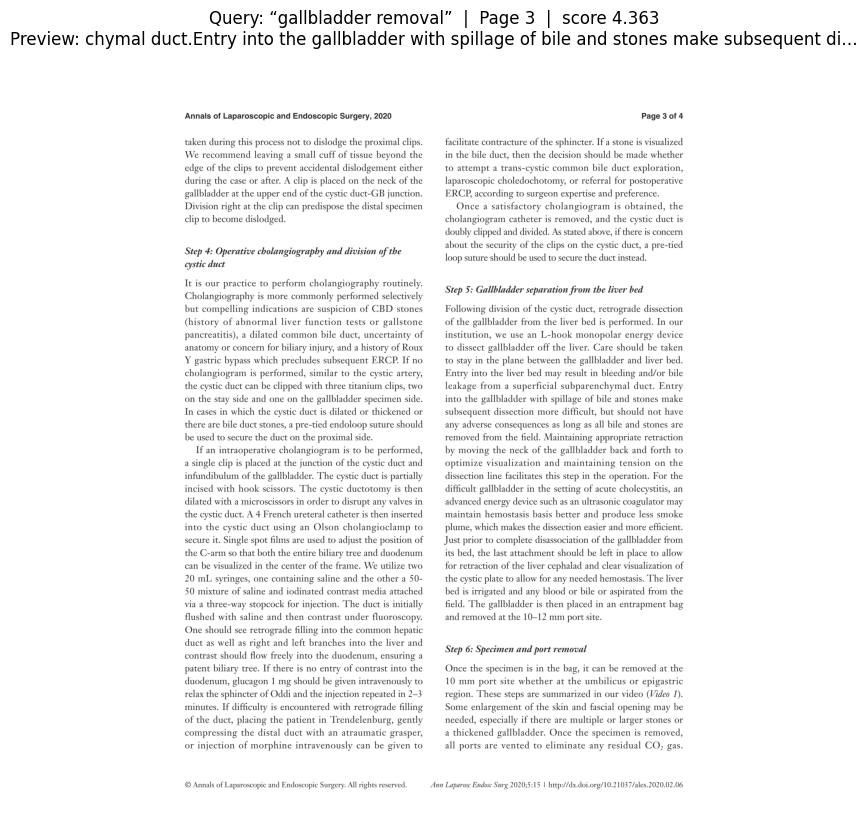

In [ ]:
page_num, hits = show_page(
    query   = "gallbladder removal",
    pdf_path= "/content/drive/MyDrive/fMRIwork/rag_docs/ales.pdf",
    index   = index,
    embedder= embedding_model,    # SentenceTransformer
    chunks  = chunks,             # corpus chunk texts
    chunk_meta = chunk_meta
)

#Generation

In [ ]:
model_id = "meta-llama/Llama-3.2-11B-Vision-Instruct"
model = MllamaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

processor = AutoProcessor.from_pretrained(model_id)

tokenizer = processor.tokenizer

config.json:   0%|          | 0.00/5.07k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/89.4k [00:00<?, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

model-00004-of-00005.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00005-of-00005.safetensors:   0%|          | 0.00/1.47G [00:00<?, ?B/s]

...

preprocessor_config.json:   0%|          | 0.00/437 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/5.09k [00:00<?, ?B/s]

In [ ]:
input_text = "What are the key steps involved in performing a safe laparoscopic cholecystectomy?"
print(f"Input text:\n{input_text}")
image = None  # Set to None - not multimodal yet


dialogue = [{"role": "user", "content": input_text}]
prompt = tokenizer.apply_chat_template(
    conversation=dialogue,
    tokenize=False,
    add_generation_prompt=True
)

inputs = processor(text=prompt, images=image, return_tensors="pt").to("cuda")

output_ids = model.generate(
    **inputs,
    max_new_tokens=512,
    do_sample=True,
    temperature=0.7,
    top_p=0.95
)

output_text = processor.tokenizer.batch_decode(output_ids, skip_special_tokens=True)[0]

print("Model Output")
print(output_text)

Input text:
What are the key steps involved in performing a safe laparoscopic cholecystectomy?
Model Output
system

Cutting Knowledge Date: December 2023
Today Date: 14 Jul 2025

user

What are the key steps involved in performing a safe laparoscopic cholecystectomy?assistant

A laparoscopic cholecystectomy is a surgical procedure to remove the gallbladder using a minimally invasive technique. Here are the key steps involved in performing a safe laparoscopic cholecystectomy:

**Pre-operative preparation**

1. **Patient selection and informed consent**: The patient is evaluated for suitability for the procedure, and informed consent is obtained.
2. **Pre-operative assessment**: The patient's medical history, laboratory tests, and imaging studies (e.g., ultrasound, CT scan) are reviewed to assess the presence of any contraindications or potential complications.
3. **Preparation of the patient**: The patient is given general anesthesia and positioned supine on the operating table.

**Lapa

In [ ]:
#Questions created by ChatGPT regarding laparoscopic cholecystectomy surgery
gpt_questions = [
"What are the key steps involved in performing a safe laparoscopic cholecystectomy?",
"What is the critical view of safety and why is it important during laparoscopic cholecystectomy?",
"What complications can arise from bile duct injury during laparoscopic cholecystectomy?",
"When is intraoperative cholangiography recommended during a laparoscopic cholecystectomy?",
"How is the patient positioned and what are the typical port placements for laparoscopic cholecystectomy?",
]


In [ ]:
query = random.choice(gpt_questions)
print(f"Query: {query}")

# Retrieve + rerank (FAISS -> BGE cross-encoder)
top_hits = search_with_rerank(
    query       = query,
    index       = index,
    embedder    = embedding_model, # same SentenceTransformer used for corpus
    dense_k     = 10,
    final_k     = 5
)

print(top_hits)

Query: What are the key steps involved in performing a safe laparoscopic cholecystectomy?
[(2.0967555046081543, 2), (1.082337737083435, 69), (0.748708963394165, 27), (-0.023173697292804718, 26), (-1.8188235759735107, 71)]


In [ ]:
def prompt_formatter(
    query: str,
    context_items: list,
    *,
    tokenizer=tokenizer,
    as_chat: bool = False      # True -> return chat-template prompt
) -> str:
    """
    Build a prompt that:
    1. Lists retrieved context chunks as bullet points.
    2. Includes 3 few-shot examples
    3. Appends the user query.

    Parameters:
    query : str
    context_items : list[str] | list[dict]
        Either raw chunk strings OR dicts containing a "text" key.
    tokenizer : transformers.PreTrainedTokenizerBase, optional
        Required only if `as_chat=True`.
    as_chat : bool, default False
        If True, formats the prompt via `tokenizer.apply_chat_template`
        for chat LLMs. Otherwise returns a plain string.
    """

    #normalize context list to strings
    ctx_strings = [
        item["text"] if isinstance(item, dict) and "text" in item else str(item)
        for item in context_items
    ]
    context_block = "- " + "\n- ".join(ctx_strings)

    # few-shot examples (experiment)
    fewshot = """
Example 1:
Query: What is the most serious complication of laparoscopic cholecystectomy?
Answer: The most serious complication is bile-duct injury (BDI). Although relatively rare (≈0.2–0.4% of cases), it can lead to re-operations, higher mortality, reduced quality of life, and litigation.

Example 2:
Query: Why is the critical view of safety important in laparoscopic cholecystectomy?
Answer: The critical view of safety prevents bile-duct injury by ensuring anatomy is clearly identified before division. It requires (1) clearing the hepatocystic triangle of fat and tissue, (2) separating the lower third of the gallbladder from the liver, and (3) seeing only two structures—the cystic duct and artery—enter the gallbladder.

Example 3:
Query: When would you use a pre-tied endoloop suture instead of clips on the cystic duct?
Answer: Use a pre-tied endoloop when the cystic duct is dilated or thickened, or if ductal stones are present, because it provides a more secure closure than standard clips.
""".strip()

    # base prompt
    base_prompt = f"""Based on the following context items, please answer the query.
Give yourself room to think by extracting relevant passages from the context before answering.
Do NOT reveal your reasoning; output only the answer in an explanatory style.

{fewshot}

Now use the context items below to answer the user query.
Context:
{context_block}

User query: {query}
Answer:"""

    # chat template
    if as_chat:
        if tokenizer is None:
            raise ValueError("tokenizer must be passed when as_chat=True")
        dialogue = [{"role": "user", "content": base_prompt}]
        return tokenizer.apply_chat_template(
            conversation     = dialogue,
            tokenize         = False,
            add_generation_prompt = True
        )

    # plain string prompt
    return base_prompt


In [ ]:
prompt = prompt_formatter(
    query          = "What are the three criteria that must be met to achieve the critical view of safety in laparoscopic cholecystectomy?",
    context_items  = [chunks[i] for _, i in hits],
    tokenizer      = tokenizer,
    as_chat        = True
)
inputs = tokenizer(prompt, return_tensors="pt").to(device)
output = model.generate(**inputs, max_new_tokens=256)
print(tokenizer.decode(output[0], skip_special_tokens=True))


system

Cutting Knowledge Date: December 2023
Today Date: 14 Jul 2025

user

Based on the following context items, please answer the query.
Give yourself room to think by extracting relevant passages from the context before answering.
Do NOT reveal your reasoning; output only the answer in an explanatory style.

Example 1:
Query: What is the most serious complication of laparoscopic cholecystectomy?
Answer: The most serious complication is bile-duct injury (BDI). Although relatively rare (≈0.2–0.4% of cases), it can lead to re-operations, higher mortality, reduced quality of life, and litigation.

Example 2:
Query: Why is the critical view of safety important in laparoscopic cholecystectomy?
Answer: The critical view of safety prevents bile-duct injury by ensuring anatomy is clearly identified before division. It requires (1) clearing the hepatocystic triangle of fat and tissue, (2) separating the lower third of the gallbladder from the liver, and (3) seeing only two structures—the cys

In [ ]:
def ask(
    query: str,
    *,
    temperature: float  = 0.3,
    max_new_tokens: int = 256,
    dense_k: int       = 20,
    final_k: int       = 5,     # after cross-encoder rerank
    return_meta: bool  = False,
):
    """
    1) FAISS dense retrieval  →  candidate indices
    2) BGE cross-encoder rerank →  top-`final_k`
    3) Prompt assembly  →  LLM generation

    Returns answer (str) or (answer, context_items) if `return_meta=True`.
    """

    #Retrieve & rerank
    hits = search_with_rerank(
        query    = query,
        index    = index,
        embedder = embedding_model,
        dense_k  = dense_k,
        final_k  = final_k,
    )
    if not hits:
        return ("No relevant passages found." if not return_meta else
                ("No relevant passages found.", []))

    # build context items
    context_items = []
    for score, idx in hits:
        meta = chunk_meta[idx]
        context_items.append({
            "text"  : chunks[idx],
            "score" : float(score),
            "page"  : meta.get("page_number", -1)
        })

    # Prompt construction
    prompt = prompt_formatter(
        query         = query,
        context_items = context_items,
        tokenizer     = tokenizer,
        as_chat       = bool(getattr(model.config, "is_decoder", False)) and
                        hasattr(tokenizer, "apply_chat_template")
    )

    # Tokenize & truncate to context window
    ctx_limit = getattr(model.config, "max_position_embeddings",
                        tokenizer.model_max_length)
    enc = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=ctx_limit
    ).to(model.device)

    # LLM generation
    with torch.no_grad():
        output_ids = model.generate(
            **enc,
            temperature      = temperature,
            do_sample        = temperature > 0,
            max_new_tokens   = max_new_tokens,
            pad_token_id     = tokenizer.eos_token_id,
        )

    raw_out = tokenizer.decode(output_ids[0],
                               skip_special_tokens=True)


    answer = raw_out.replace(prompt, "").strip()

    # Clean-up
    junk_phrases = [
        "Sure, here is the answer:",
        "Certainly:",
        "Certainly. ",
    ]
    for jp in junk_phrases:
        answer = answer.replace(jp, "")
    answer = answer.replace("\n\n\n", "\n\n").strip()

    if return_meta:
        return answer, context_items
    return answer


In [ ]:
response, ctx = ask(
    "Why is a critical view of safety essential?",
    return_meta=True
)
print(response)
for c in ctx:
    print(f"[p{c['page']+1}] score={c['score']:.3f}  {c['text'][:90]}…")

Based on the following context items, please answer the query.
Give yourself room to think by extracting relevant passages from the context before answering.
Do NOT reveal your reasoning; output only the answer in an explanatory style.

Example 1:
Query: What is the most serious complication of laparoscopic cholecystectomy?
Answer: The most serious complication is bile-duct injury (BDI). Although relatively rare (≈0.2–0.4% of cases), it can lead to re-operations, higher mortality, reduced quality of life, and litigation.

Example 2:
Query: Why is the critical view of safety important in laparoscopic cholecystectomy?
Answer: The critical view of safety prevents bile-duct injury by ensuring anatomy is clearly identified before division. It requires (1) clearing the hepatocystic triangle of fat and tissue, (2) separating the lower third of the gallbladder from the liver, and (3) seeing only two structures—the cystic duct and artery—enter the gallbladder.

Example 3:
Query: When would you 

In [ ]:
response, ctx = ask(
    "During a laparoscopic cholecystectomy, what routine or selective indications do the authors give for performing an intra-operative cholangiogram, and how is the cystic duct prepared for catheter insertion?",
    return_meta=True
)
print(response)
for c in ctx:
    print(f"[p{c['page']+1}] score={c['score']:.3f}  {c['text'][:90]}…")

Based on the following context items, please answer the query.
Give yourself room to think by extracting relevant passages from the context before answering.
Do NOT reveal your reasoning; output only the answer in an explanatory style.

Example 1:
Query: What is the most serious complication of laparoscopic cholecystectomy?
Answer: The most serious complication is bile-duct injury (BDI). Although relatively rare (≈0.2–0.4% of cases), it can lead to re-operations, higher mortality, reduced quality of life, and litigation.

Example 2:
Query: Why is the critical view of safety important in laparoscopic cholecystectomy?
Answer: The critical view of safety prevents bile-duct injury by ensuring anatomy is clearly identified before division. It requires (1) clearing the hepatocystic triangle of fat and tissue, (2) separating the lower third of the gallbladder from the liver, and (3) seeing only two structures—the cystic duct and artery—enter the gallbladder.

Example 3:
Query: When would you 

# Evaluation

In [ ]:
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

In [ ]:
query_pool = [
    "What are the three criteria that define the critical view of safety?",
    "When do the authors recommend performing an intra-operative cholangiogram?",
    "List common complications after laparoscopic cholecystectomy.",
    "Which energy device is preferred for retrograde dissection of the gallbladder?",
    "How is the patient positioned to facilitate cholangiography?",
    "What clip strategy is used for the cystic artery?",
    "What is the critical view of safety?",
    "When should antibiotics be used in laparoscopic cholecystectomy?",
    "What are the indications for laparoscopic cholecystectomy?",
    "What are the contraindications for laparoscopic surgery?",
    "How should common bile duct stones be managed?",
]

In [ ]:
gpt_model  = "gpt-4o-mini"
encoder = tiktoken.encoding_for_model(gpt_model)
OPENAI_KEY = os.getenv("OPENAI_API_KEY")
rt_limit = 60
openai.api_key = OPENAI_KEY
client  = openai.AsyncOpenAI()
limiter = AsyncLimiter(rt_limit, time_period=60)  # 60 requests / 60 s

In [ ]:
async def judge(prompt: str,
                max_tokens: int = 1,
                temperature: float = 0.0) -> str:
    """
    Single OpenAI chat completion call in an aiolimiter slot.
    Returns stripped assistant content string.
    """
    async with limiter:
        resp = await client.chat.completions.create(
            model       = gpt_model,
            temperature = temperature,
            max_tokens  = max_tokens,
            messages=[
                {"role": "system",
                 "content": "You are a strict evaluator. "
                            "Answer ONLY with the requested rating/number."},
                {"role": "user", "content": prompt}
            ],
        )
    return resp.choices[0].message.content.strip()

In [ ]:
async def context_precision(query: str,
                            chunk_texts: list[str]) -> float:
    """
    Precision@k  – % of chunks that GPT judges as relevant to the query.
    """
    template = (
        "Question: {q}\n\n"
        "Chunk:\n\"\"\"{c}\"\"\"\n\n"
        "Does this chunk help answer the question? Reply only YES or NO."
    )

    tasks = [
        judge(template.format(q=query, c=chunk[:4096]))
        for chunk in chunk_texts
    ]
    results = await asyncio.gather(*tasks)
    scores  = [1.0 if r.lower().startswith("y") else 0.0 for r in results]
    return sum(scores) / len(scores)

In [ ]:
async def fluency_coherence(answer: str) -> dict:
    """
    Returns {"fluency":int, "coherence":int} on 1-5 scale.
    """
    prompt = (
        "Rate the answer below on a 1-5 integer scale for each trait.\n\n"
        "Traits: (A) Fluency/Grammar, (B) Coherence/Logical-flow.\n\n"
        "Return JSON exactly like {\"fluency\":4, \"coherence\":5}.\n\n"
        f"Answer:\n\"\"\"{answer[:4096]}\"\"\""
    )
    resp = await judge(prompt, max_tokens=20)
    try:
        return json.loads(resp)
    except Exception:
        return {"fluency": 1, "coherence": 1}

In [ ]:
async def faithfulness_score(answer: str,
                             context: str) -> float:
    """
    0-1 score: how well the context supports every factual claim.
    """
    prompt = (
        "Context:\n\"\"\"{ctx}\"\"\"\n\n"
        "Answer:\n\"\"\"{ans}\"\"\"\n\n"
        "Does the Context completely support every factual claim in the Answer?\n"
        "Respond with a single number between 0 (no support) and 1 (fully supported)."
    ).format(ctx=context[:4096], ans=answer[:2048])

    resp = await judge(prompt, max_tokens=3)
    try:
        return float(resp.split()[0])
    except ValueError:
        return 0.0

In [ ]:
#Eval Loop
async def evaluate_queries(query_pool: list[str],
                           *,
                           dense_k: int = 20,
                           final_k: int = 5) -> None:

    latencies, precisions, flu, coh, halluc = [], [], [], [], []

    for query in query_pool:
        t0 = time.perf_counter()

        # RAG pipeline
        answer, ctx_items = ask(
            query,
            dense_k=dense_k,
            final_k=final_k,
            temperature=0.2,
            return_meta=True
        )
        latency = time.perf_counter() - t0
        latencies.append(latency)

        chunks = [c["text"] for c in ctx_items]
        joined = "\n\n".join(chunks)

        # GPT-based metrics
        prec  = await context_precision(query, chunks)
        fc    = await fluency_coherence(answer)
        faith = await faithfulness_score(answer, joined)

        precisions.append(prec)
        flu.append(fc["fluency"])
        coh.append(fc["coherence"])
        halluc.append(1 if faith < 0.3 else 0)

        print(f"{query[:38]:<38} | lat {latency:4.2f}s | "
              f"prec {prec:.2f} | faith {faith:.2f}")

    # summary
    print("\n──────── Summary (GPT-4o Judge) ────────")
    print(f"Avg latency        : {statistics.mean(latencies):.2f}s  "
          f"(p99 {max(latencies):.2f}s)")
    print(f"Precision@{final_k}: {statistics.mean(precisions):.3f}")
    print(f"Fluency (1-5)      : {statistics.mean(flu):.2f}")
    print(f"Coherence (1-5)    : {statistics.mean(coh):.2f}")
    print(f"Hallucination rate : {100*sum(halluc)/len(halluc):.1f}%")


#Run of Sample set
nest_asyncio.apply()

random.seed(42)
SAMPLE_QUERIES = random.sample(query_pool, k=min(30, len(query_pool)))

await evaluate_queries(SAMPLE_QUERIES, dense_k=20, final_k=5)

How should common bile duct stones be  | lat 21.09s | prec 0.60 | faith 1.00
When do the authors recommend performi | lat 22.03s | prec 0.80 | faith 1.00
What are the three criteria that defin | lat 20.31s | prec 0.00 | faith 1.00
How is the patient positioned to facil | lat 21.94s | prec 0.20 | faith 1.00
What are the contraindications for lap | lat 21.30s | prec 0.60 | faith 1.00
What is the critical view of safety?   | lat 20.33s | prec 0.20 | faith 1.00
What clip strategy is used for the cys | lat 22.07s | prec 0.40 | faith 1.00
What are the indications for laparosco | lat 20.95s | prec 0.40 | faith 1.00
List common complications after laparo | lat 20.37s | prec 0.40 | faith 1.00
Which energy device is preferred for r | lat 21.68s | prec 0.40 | faith 1.00
When should antibiotics be used in lap | lat 22.49s | prec 0.40 | faith 0.00

──────── Summary (GPT-4o Judge) ────────
Avg latency        : 21.32s  (p99 22.49s)
Precision@5: 0.400
Fluency (1-5)      : 3.82
Coherence (1-5)    : 4.0